In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.predict import Predictor, ThresholdItemPredictor
from utils.split import FrequencyBandSplitter, FrequencyBandEvaluator
from utils.analysis import DatasetProfiler, analyze_biases_with_counts
from model.PMF import MatrixFactorization
from model.BPMF import BayesianPMF, BayesianPMFWithBiases
from model.NNBPMF import BayesianNonNegativeMF
from ensemble.ensemble import RatingEnsemble, ThresholdEnsembleModel, ManualRoutingEnsemble
from ensemble.adaptative import AdaptiveColdStartEnsemble, AdaptivePosteriorColdStartEnsemble
from sklearn.model_selection import train_test_split
import random

from model.PMF import SurpriseNMFModel
from model.baseline import SurpriseBaselineOnlyModel, SurpriseKNNBaselineWrapper


In [2]:
TRAIN_PATH = '../data/train.csv'

full_data = pd.read_csv(TRAIN_PATH)

train_data, test_data = train_test_split(full_data, test_size=0.1, random_state=42)

train_data

,user,item,rating
65957,8352,155705,6.0
36595,4201,103532,9.0
74297,9619,168399,7.0
307818,59525,29423,8.0
90711,12518,29534,8.0
...,...,...,...
259178,48916,133274,7.0
365838,72117,177149,8.0
131932,21683,38124,8.0
146867,25312,26784,10.0


In [3]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(full_data, test_size=0.15, random_state=42)

len(train_data), len(test_data)

(331798, 58553)

# 0. Análisis

In [13]:
profiler = DatasetProfiler(user_col='user', item_col='item', rating_col='rating')

profiler.fit(train_data)
profiler.print_report()

RECOMMENDER DATASET REPORT

[1] DATASET SUMMARY
  - n_interactions: 331798
  - n_users: 66691
  - n_items: 152546
  - density: 0.0
  - sparsity: 1.0
  - avg_interactions_per_user: 4.9752
  - avg_interactions_per_item: 2.1751
  - rating_mean: 7.6027
  - rating_std: 1.8417
  - rating_min: 1.0
  - rating_max: 10.0
  - rating_median: 8.0

[2] USER PROFILE
  - n_users: 66691
  - min_interactions: 1
  - max_interactions: 5113
  - mean_interactions: 4.9752
  - median_interactions: 1.0
  - std_interactions: 30.8705
  - p25_interactions: 1.0
  - p75_interactions: 3.0
  - p90_interactions: 8.0
  - p95_interactions: 17.0
  - p99_interactions: 64.0
  - share_with_1_interaction: 0.5887
  - share_with_le_2_interactions: 0.7188
  - share_with_le_5_interactions: 0.855
  - share_with_le_10_interactions: 0.9204
  - share_with_ge_10_interactions: 0.0875
  - share_with_ge_20_interactions: 0.0422
  - head_1pct_interaction_share: 0.3006
  - head_5pct_interaction_share: 0.55
  - head_10pct_interaction_share:

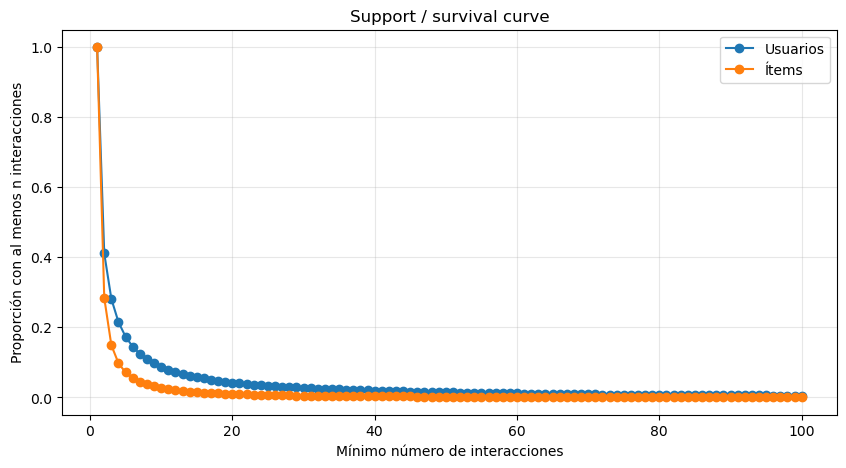

In [14]:
profiler.plot_support_curves()

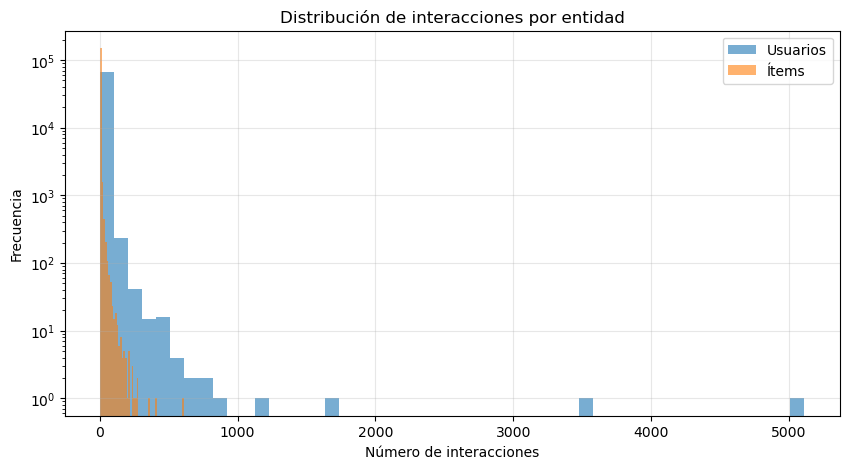

In [15]:
profiler.plot_count_distributions()

In [16]:
TEST_PATH = '../data/test.csv'

main_test_data = pd.read_csv(TEST_PATH)

main_test_data = test_data[['user', 'item']]

main_test_data = pd.concat([test_data, pd.DataFrame({'rating': np.nan}, index=test_data.index)], axis=1)

test_profiler = DatasetProfiler(user_col='user', item_col='item', rating_col='rating')

test_profiler.fit(test_data)
test_profiler.print_report()

RECOMMENDER DATASET REPORT

[1] DATASET SUMMARY
  - n_interactions: 58553
  - n_users: 22941
  - n_items: 40178
  - density: 0.0001
  - sparsity: 0.9999
  - avg_interactions_per_user: 2.5523
  - avg_interactions_per_item: 1.4573
  - rating_mean: 7.6156
  - rating_std: 1.8491
  - rating_min: 1.0
  - rating_max: 10.0
  - rating_median: 8.0

[2] USER PROFILE
  - n_users: 22941
  - min_interactions: 1
  - max_interactions: 879
  - mean_interactions: 2.5523
  - median_interactions: 1.0
  - std_interactions: 9.0963
  - p25_interactions: 1.0
  - p75_interactions: 2.0
  - p90_interactions: 5.0
  - p95_interactions: 8.0
  - p99_interactions: 22.6
  - share_with_1_interaction: 0.6638
  - share_with_le_2_interactions: 0.8038
  - share_with_le_5_interactions: 0.9186
  - share_with_le_10_interactions: 0.9663
  - share_with_ge_10_interactions: 0.0386
  - share_with_ge_20_interactions: 0.0127
  - head_1pct_interaction_share: 0.1909
  - head_5pct_interaction_share: 0.3854
  - head_10pct_interaction_sh

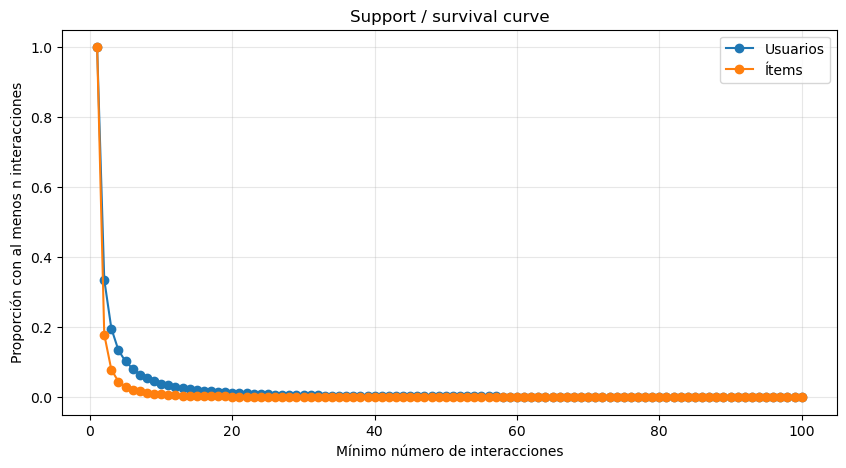

In [17]:
test_profiler.plot_support_curves()

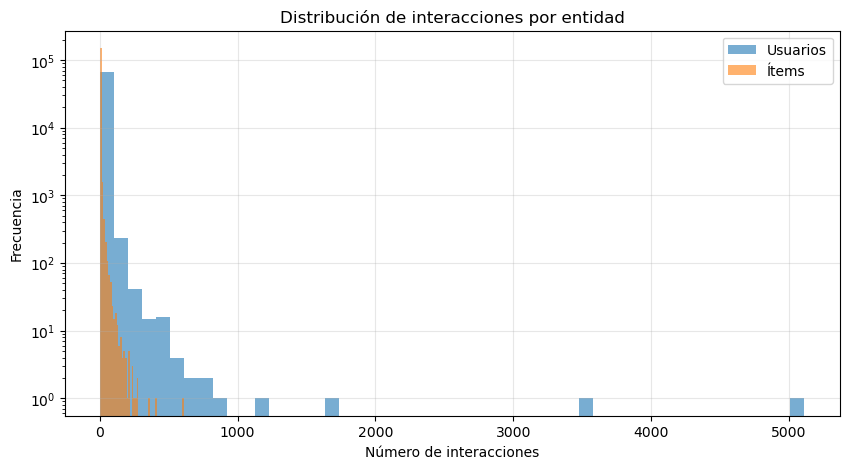

In [18]:
profiler.plot_count_distributions()

# 1. Modelos

In [9]:
splitter = FrequencyBandSplitter(mode="threshold", low_threshold=1, high_threshold=7)
splitter.fit(train_data)
evaluator = FrequencyBandEvaluator(splitter)

## 1.1 Muchos PMF 

In [20]:
mf_10 = MatrixFactorization(n_factors=4, n_epochs=40, lr=0.1, reg=0.5, verbose=False)

mf_20 = MatrixFactorization(n_factors=6, n_epochs=40, lr=0.1, reg=0.1, verbose=False)

mf_30 = MatrixFactorization(n_factors=8, n_epochs=40, lr=0.1, reg=0.1, verbose=False)

mf_40 = MatrixFactorization(n_factors=15, n_epochs=75, lr=0.05, reg=0.5, verbose=False)

mf_50 = MatrixFactorization(n_factors=20, n_epochs=100, lr=0.05, reg=0.1, verbose=False)

models = [mf_10, mf_20, mf_30, mf_40, mf_50]

for model in models:
    model.fit(train_data)
    predictions = model.predict_df(test_data)
    errors = np.abs(predictions['rating'] - predictions['prediction'])
    print(f'Mean Absolute Error for {model.n_factors} factors: {errors.mean():.4f}')

    print(evaluator.evaluate(model, predictions))

Mean Absolute Error for 4 factors: 1.3412
   band  n_rows      rmse       mae
0  high   19652  1.623056  1.268835
1   low   26701  1.773823  1.399955
2   mid   12200  1.704337  1.328984
Mean Absolute Error for 6 factors: 1.3651
   band  n_rows      rmse       mae
0  high   19652  1.760937  1.349004
1   low   26701  1.748614  1.367548
2   mid   12200  1.792815  1.385575
Mean Absolute Error for 8 factors: 1.3570
   band  n_rows      rmse       mae
0  high   19652  1.744354  1.344893
1   low   26701  1.741052  1.362322
2   mid   12200  1.770373  1.364957
Mean Absolute Error for 15 factors: 1.3321
   band  n_rows      rmse       mae
0  high   19652  1.602088  1.254421
1   low   26701  1.765006  1.393845
2   mid   12200  1.692097  1.321855
Mean Absolute Error for 20 factors: 1.3280
   band  n_rows      rmse       mae
0  high   19652  1.647821  1.275883
1   low   26701  1.736515  1.366360
2   mid   12200  1.708605  1.328058


Mean Absolute Error for Ensemble: 1.2996


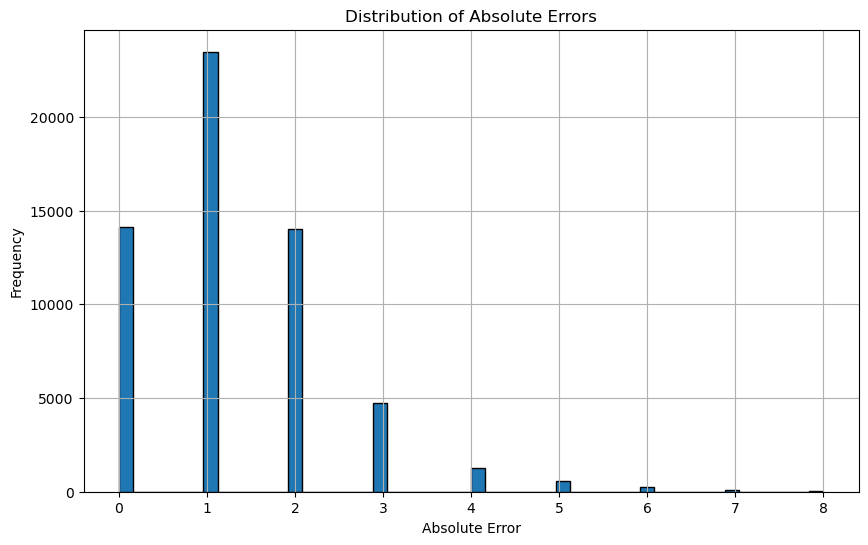

In [21]:
ensemble = RatingEnsemble(models=models, weights=[0.2, 0.2, 0.2, 0.2, 0.2], strategy='mean', clip_range=(0, 10))

ensemble_predictions = ensemble.predict_df(test_data, round_predictions=True)

ensemble_errors = np.abs(ensemble_predictions['rating'] - ensemble_predictions['prediction'])
print(f'Mean Absolute Error for Ensemble: {ensemble_errors.mean():.4f}')

plt.figure(figsize=(10, 6))
plt.hist(ensemble_errors, bins=50, edgecolor='k')
plt.xlabel('Absolute Error')
plt.ylabel('Frequency')
plt.title('Distribution of Absolute Errors')
plt.grid()
plt.show()

## 1.2 Modelos de Surprise

In [ ]:
baseline_model_1 = SurpriseBaselineOnlyModel()
baseline_model_1.fit(train_data)

baseline_predictions_1 = baseline_model_1.predict_df(test_data, round_predictions=True)

mae_baseline_1 = np.mean(np.abs(baseline_predictions_1['prediction'] - test_data['rating']))

print(f'MAE for Baseline Model: {mae_baseline_1}')

evaluator.evaluate(baseline_model_1, test_data)

MAE for Baseline Model: 1.253377282120472


,band,n_rows,rmse,mae
0,high,19652,1.590138,1.235578
1,low,26701,1.699181,1.311959
2,mid,12200,1.640310,1.272325


In [29]:
baseline_model_2 = SurpriseBaselineOnlyModel(bsl_options={'method': 'sgd', 'n_epochs': 100, 'reg_u': 0.02, 'reg_i': 0.02})
baseline_model_2.fit(train_data)

baseline_predictions_2 = baseline_model_2.predict_df(test_data, round_predictions=True)
mae_baseline_2 = np.mean(np.abs(baseline_predictions_2['prediction'] - test_data['rating']))

print(f'MAE for Baseline Model: {mae_baseline_2}')

evaluator.evaluate(baseline_model_2, test_data)

MAE for Baseline Model: 1.2473143989206361


,band,n_rows,rmse,mae
0,high,19652,1.590495,1.219708
1,low,26701,1.684243,1.288939
2,mid,12200,1.689008,1.298621


In [17]:
nmf = SurpriseNMFModel(n_factors=15, n_epochs=70, biased=False, verbose=False, reg_pu=0.05, reg_qi=0.05, init_low=0.001, init_high=0.1)
nmf.fit(train_data)

nmf_predictions = nmf.predict_df(test_data, round_predictions=True)
mae_nmf = np.mean(np.abs(nmf_predictions['prediction'] - test_data['rating']))
print(f'MAE for NMF Model: {mae_nmf}')

evaluator.evaluate(nmf, test_data)

MAE for NMF Model: 3.1446211124963708


,band,n_rows,rmse,mae
0,high,19652,4.239604,3.850519
1,low,26701,2.932588,2.297813
2,mid,12200,4.339207,3.943527


In [18]:
nmf_2 = SurpriseNMFModel(n_factors=15, n_epochs=40, biased=True, verbose=False, reg_pu=0.5, reg_qi=0.5, init_low=0.001, init_high=0.001, reg_bu=0.0002, reg_bi=0.0002)
nmf_2.fit(train_data)

nmf_2_predictions = nmf_2.predict_df(test_data, round_predictions=True)
mae_nmf_2 = np.mean(np.abs(nmf_2_predictions['prediction'] - test_data['rating']))
print(f'MAE for NMF Model: {mae_nmf_2}')

evaluator.evaluate(nmf_2, test_data)

MAE for NMF Model: 1.2285621573617065


,band,n_rows,rmse,mae
0,high,19652,1.583102,1.217961
1,low,26701,1.670892,1.275603
2,mid,12200,1.632178,1.256183


In [19]:
nmf_3 = SurpriseNMFModel(n_factors=8, n_epochs=40, biased=True, verbose=False, reg_pu=0.5, reg_qi=0.5, init_low=0.001, init_high=0.001, reg_bu=0.0002, reg_bi=0.0002)

nmf_3.fit(train_data)

nmf_3_predictions = nmf_3.predict_df(test_data, round_predictions=True)
mae_nmf_3 = np.mean(np.abs(nmf_3_predictions['prediction'] - test_data['rating']))
print(f'MAE for NMF Model: {mae_nmf_3}')

evaluator.evaluate(nmf_3, test_data)

MAE for NMF Model: 1.2284084504636825


,band,n_rows,rmse,mae
0,high,19652,1.583114,1.217967
1,low,26701,1.670830,1.275585
2,mid,12200,1.632010,1.256101


In [30]:
ensemble = RatingEnsemble(models=[baseline_model_2, nmf_2, nmf_3], strategy='mean', clip_range=(1, 10))
ensemble_predictions = ensemble.predict_df(test_data, round_predictions=True)
mae_ensemble = np.mean(np.abs(ensemble_predictions['prediction'] - test_data['rating']))
print(f'MAE for Ensemble Model: {mae_ensemble}')

evaluator.evaluate(ensemble, test_data)

MAE for Ensemble Model: 1.2307140539340427


,band,n_rows,rmse,mae
0,high,19652,1.583136,1.216858
1,low,26701,1.671875,1.277695
2,mid,12200,1.643887,1.264911


In [34]:
import gc
gc.collect()

220118

In [ ]:
knn = SurpriseKNNBaselineWrapper(
    k=50,
    min_k=3,
    user_based=True,
    sim_name="pearson_baseline",
    shrinkage=200,
    bsl_options={
        "method": "als",
        "n_epochs": 10,
        "reg_u": 3,
        "reg_i": 3,
    },
    clip_range=(1, 10),
    unknown_strategy="surprise",
    verbose=True,
    name="KNNBaselineUser"
)

train_data_knn, test_data_knn = train_test_split(full_data, test_size=0.5, random_state=42)

knn.fit(train_data_knn)
predictions_knn = knn.predict_df(test_data_knn, round_predictions=True)
mae_knn = np.mean(np.abs(predictions_knn['prediction'] - test_data_knn['rating']))
print(f'MAE for KNN Baseline: {mae_knn}')

evaluator.evaluate(knn, test_data_knn)

In [ ]:
knn = SurpriseKNNBaselineWrapper(
    k=30,
    min_k=6,
    user_based=True,
    sim_name="pearson_baseline",
    shrinkage=100,
    bsl_options={
        "method": "als",
        "n_epochs": 15,
        "reg_u": 3,
        "reg_i": 3,
    },
    clip_range=(1, 10),
    unknown_strategy="surprise",
    verbose=True,
    name="KNNBaselineItem"
)

knn.fit(train_data_knn)
predictions_knn = knn.predict_df(test_data_knn, round_predictions=True)
mae_knn = np.mean(np.abs(predictions_knn['prediction'] - test_data_knn['rating']))
print(f'MAE for KNN Baseline: {mae_knn}')

evaluator.evaluate(knn, test_data_knn)

## 1.3 Bayesian Matrix Factorization

### 1.3.1 Bayesian Matrix Factorization

In [31]:
bayesian_pmf = BayesianPMF(n_factors=20, n_iters=50, burn_in=20, verbose=True, rating_std=1)
bayesian_pmf.fit(train_data)

bayesian_pmf_predictions = bayesian_pmf.predict_df(test_data, round_predictions=True)
mae_bayesian_pmf = np.mean(np.abs(bayesian_pmf_predictions['prediction'] - test_data['rating']))
print(f'MAE for Bayesian PMF: {mae_bayesian_pmf}')

evaluator.evaluate(bayesian_pmf, test_data)

[BayesianPMF] iter 1/50 - train_rmse=1.83836
[BayesianPMF] iter 5/50 - train_rmse=1.83476
[BayesianPMF] iter 10/50 - train_rmse=1.83035
[BayesianPMF] iter 15/50 - train_rmse=1.82694
[BayesianPMF] iter 20/50 - train_rmse=1.81729
[BayesianPMF] iter 25/50 - train_rmse=1.79203
[BayesianPMF] iter 30/50 - train_rmse=1.69845
[BayesianPMF] iter 35/50 - train_rmse=1.40998
[BayesianPMF] iter 40/50 - train_rmse=1.28549
[BayesianPMF] iter 45/50 - train_rmse=1.26531
[BayesianPMF] iter 50/50 - train_rmse=1.25915
MAE for Bayesian PMF: 1.3473775895342681


,band,n_rows,rmse,mae
0,high,19652,1.695388,1.347722
1,low,26701,1.765179,1.398916
2,mid,12200,1.729048,1.368992


In [32]:
bayesian_pmf_low_std = BayesianPMF(n_factors=10, n_iters=75, burn_in=20, verbose=True, rating_std=0.8)
bayesian_pmf_low_std.fit(train_data)

bayesian_pmf_low_std_predictions = bayesian_pmf_low_std.predict_df(test_data, round_predictions=True)
mae_bayesian_pmf_low_std = np.mean(np.abs(bayesian_pmf_low_std_predictions['prediction'] - test_data['rating']))
print(f'MAE for Bayesian PMF (low std): {mae_bayesian_pmf_low_std}')

evaluator.evaluate(bayesian_pmf_low_std, test_data)

[BayesianPMF] iter 1/75 - train_rmse=1.83875
[BayesianPMF] iter 7/75 - train_rmse=1.81727
[BayesianPMF] iter 14/75 - train_rmse=1.78256
[BayesianPMF] iter 21/75 - train_rmse=1.30217
[BayesianPMF] iter 28/75 - train_rmse=1.14142
[BayesianPMF] iter 35/75 - train_rmse=1.12556
[BayesianPMF] iter 42/75 - train_rmse=1.09689
[BayesianPMF] iter 49/75 - train_rmse=1.04735
[BayesianPMF] iter 56/75 - train_rmse=1.00833
[BayesianPMF] iter 63/75 - train_rmse=0.99464
[BayesianPMF] iter 70/75 - train_rmse=0.99140
MAE for Bayesian PMF (low std): 1.3442522159411132


,band,n_rows,rmse,mae
0,high,19652,1.753731,1.335487
1,low,26701,1.779718,1.373735
2,mid,12200,1.888970,1.431172


In [33]:
bayesian_pmf_with_biases = BayesianPMFWithBiases(n_factors=10, n_iters=50, burn_in=20, verbose=True, rating_std=0.8, user_bias_std=0.5, item_bias_std=0.5)

bayesian_pmf_with_biases.fit(train_data)
bayesian_pmf_with_biases_predictions = bayesian_pmf_with_biases.predict_df(test_data, round_predictions=True)
mae_bayesian_pmf_with_biases = np.mean(np.abs(bayesian_pmf_with_biases_predictions['prediction'] - test_data['rating']))
print(f'MAE for Bayesian PMF with Biases: {mae_bayesian_pmf_with_biases}')

evaluator.evaluate(bayesian_pmf_with_biases, test_data)

[BayesianPMFWithBiases] iter 1/50 - train_rmse=1.29427
[BayesianPMFWithBiases] iter 5/50 - train_rmse=1.28941
[BayesianPMFWithBiases] iter 10/50 - train_rmse=1.28542
[BayesianPMFWithBiases] iter 15/50 - train_rmse=1.28353
[BayesianPMFWithBiases] iter 20/50 - train_rmse=1.28251
[BayesianPMFWithBiases] iter 25/50 - train_rmse=1.28118
[BayesianPMFWithBiases] iter 30/50 - train_rmse=1.27820
[BayesianPMFWithBiases] iter 35/50 - train_rmse=1.27120
[BayesianPMFWithBiases] iter 40/50 - train_rmse=1.25282
[BayesianPMFWithBiases] iter 45/50 - train_rmse=1.19406
[BayesianPMFWithBiases] iter 50/50 - train_rmse=1.06014
MAE for Bayesian PMF with Biases: 1.2380578279507455


,band,n_rows,rmse,mae
0,high,19652,1.588495,1.222721
1,low,26701,1.677138,1.284727
2,mid,12200,1.643082,1.266192


In [34]:
bayesian_pmf_with_biases = BayesianPMFWithBiases(n_factors=10, n_iters=50, burn_in=20, verbose=True, rating_std=0.4, user_bias_std=0.2, item_bias_std=0.2)

bayesian_pmf_with_biases.fit(train_data)
bayesian_pmf_with_biases_predictions = bayesian_pmf_with_biases.predict_df(test_data, round_predictions=True)
mae_bayesian_pmf_with_biases = np.mean(np.abs(bayesian_pmf_with_biases_predictions['prediction'] - test_data['rating']))
print(f'MAE for Bayesian PMF with Biases: {mae_bayesian_pmf_with_biases}')

evaluator.evaluate(bayesian_pmf_with_biases, test_data)

[BayesianPMFWithBiases] iter 1/50 - train_rmse=1.31467
[BayesianPMFWithBiases] iter 5/50 - train_rmse=1.19145
[BayesianPMFWithBiases] iter 10/50 - train_rmse=0.56462
[BayesianPMFWithBiases] iter 15/50 - train_rmse=0.46128
[BayesianPMFWithBiases] iter 20/50 - train_rmse=0.43880
[BayesianPMFWithBiases] iter 25/50 - train_rmse=0.42946
[BayesianPMFWithBiases] iter 30/50 - train_rmse=0.42259
[BayesianPMFWithBiases] iter 35/50 - train_rmse=0.41896
[BayesianPMFWithBiases] iter 40/50 - train_rmse=0.41654
[BayesianPMFWithBiases] iter 45/50 - train_rmse=0.41449
[BayesianPMFWithBiases] iter 50/50 - train_rmse=0.41384
MAE for Bayesian PMF with Biases: 1.445596297371612


,band,n_rows,rmse,mae
0,high,19652,2.061030,1.575194
1,low,26701,1.787608,1.383221
2,mid,12200,1.928512,1.476742


In [35]:
user_bias, item_bias = analyze_biases_with_counts(train_data, bayesian_pmf_with_biases)

=== USERS más extremos ===
       user  user_bias  n_user_ratings  abs_user_bias
475   41597  -2.589077             386       2.589077
796   45489  -2.529387             192       2.529387
144    7906  -2.523992            1153       2.523992
862   76969  -2.477204             127       2.477204
2526   7730  -2.456455             451       2.456455
3419  51352  -2.446535              92       2.446535
710   50871  -2.338667             127       2.338667
359   55265   2.303847             140       2.303847
1085  69683   2.176200              95       2.176200
7738  49159   2.175157              71       2.175157
623   66560  -2.173751              82       2.173751
231   19532   2.170931             345       2.170931
885   74882  -2.110496             238       2.110496
2762  77187   2.037554             181       2.037554
5772  18300   2.023306              72       2.023306
5934  12446   2.008531              42       2.008531
3861  46089  -2.006127              38       2.006127
3

In [43]:
bpmf_with_biases = BayesianPMFWithBiases(n_factors=8, n_iters=50, burn_in=20, rating_std=1, user_bias_std=0.8, item_bias_std=0.8, clip_range=(0, 10))
bpmf_with_biases.fit(train_data)

bpmf_with_biases_predictions = bpmf_with_biases.predict_df(test_data, round_predictions=True)
mae_bpmf_with_biases = np.mean(np.abs(bpmf_with_biases_predictions['prediction'] - test_data['rating']))
print(f'MAE for BPMF with Biases Model: {mae_bpmf_with_biases}')

evaluator.evaluate(bpmf_with_biases, test_data)

[BayesianPMFWithBiases] iter 1/50 - train_rmse=1.27448
[BayesianPMFWithBiases] iter 5/50 - train_rmse=1.27305
[BayesianPMFWithBiases] iter 10/50 - train_rmse=1.27114
[BayesianPMFWithBiases] iter 15/50 - train_rmse=1.27286
[BayesianPMFWithBiases] iter 20/50 - train_rmse=1.27226
[BayesianPMFWithBiases] iter 25/50 - train_rmse=1.27247
[BayesianPMFWithBiases] iter 30/50 - train_rmse=1.27165
[BayesianPMFWithBiases] iter 35/50 - train_rmse=1.27070
[BayesianPMFWithBiases] iter 40/50 - train_rmse=1.27193
[BayesianPMFWithBiases] iter 45/50 - train_rmse=1.26995
[BayesianPMFWithBiases] iter 50/50 - train_rmse=1.27160
MAE for BPMF with Biases Model: 1.246528785886291


,band,n_rows,rmse,mae
0,high,19652,1.585065,1.217213
1,low,26701,1.688918,1.293321
2,mid,12200,1.670575,1.286305


In [44]:
user_bias, item_bias = analyze_biases_with_counts(train_data, bpmf_with_biases)

=== USERS más extremos ===
        user  user_bias  n_user_ratings  abs_user_bias
36000  58455  -4.254935               4       4.254935
26789   5823  -3.827512              13       3.827512
25214  69556  -3.783061               6       3.783061
5880   60396  -3.678767              46       3.678767
7425   26282  -3.509290               9       3.509290
23469  66094  -3.503341              15       3.503341
12236  32919  -3.439500              13       3.439500
28166  28736  -3.413859               2       3.413859
20410  20863  -3.406771               2       3.406771
39607  22657  -3.351763               6       3.351763
29951  24844  -3.300344               6       3.300344
11677  36365  -3.264516               3       3.264516
40641  37353  -3.243107               2       3.243107
16542  25768  -3.223066              13       3.223066
30589  65270  -3.158642               2       3.158642
11844   4082  -3.133879               4       3.133879
18551  47436  -3.115291               

In [ ]:
ensemble = RatingEnsemble(models=[bayesian_pmf, bayesian_pmf_low_std, bpmf_with_biases], weights=[0.33, 0.33, 0.34], strategy='mean', clip_range=(1, 10))

evaluator.evaluate(ensemble, test_data)

,band,n_rows,rmse,mae
0,high,19652,1.692338,1.319492
1,low,26701,1.740086,1.360411
2,mid,12200,1.733667,1.348574


### 1.3.2 BayesianNonNegative

In [37]:
bayesian_nnmf = BayesianNonNegativeMF(n_factors=8, n_iters=40, alpha=0.5, beta=5, R=10, init_noise=1e-3)

bayesian_nnmf.fit(train_data)

evaluator.evaluate(bayesian_nnmf, test_data)

[BayesianNonNegativeMF] iter 1/40 - train_mae_map=1.97514 - train_mae_exp=2.00012 - user_entropy=2.07944 - peak_resp=0.12607 - item_factor_std=0.04169
[BayesianNonNegativeMF] iter 4/40 - train_mae_map=1.97537 - train_mae_exp=2.00009 - user_entropy=2.07943 - peak_resp=0.12745 - item_factor_std=0.04170
[BayesianNonNegativeMF] iter 8/40 - train_mae_map=1.96717 - train_mae_exp=1.99585 - user_entropy=2.07827 - peak_resp=0.14736 - item_factor_std=0.04252
[BayesianNonNegativeMF] iter 12/40 - train_mae_map=1.83168 - train_mae_exp=1.88178 - user_entropy=2.04599 - peak_resp=0.31297 - item_factor_std=0.05276
[BayesianNonNegativeMF] iter 16/40 - train_mae_map=1.62735 - train_mae_exp=1.71012 - user_entropy=1.97559 - peak_resp=0.54496 - item_factor_std=0.06067
[BayesianNonNegativeMF] iter 20/40 - train_mae_map=1.50590 - train_mae_exp=1.60655 - user_entropy=1.92582 - peak_resp=0.68261 - item_factor_std=0.06362
[BayesianNonNegativeMF] iter 24/40 - train_mae_map=1.44639 - train_mae_exp=1.55599 - user_e

,band,n_rows,rmse,mae
0,high,19652,2.175009,1.721504
1,low,26701,3.101886,2.649227
2,mid,12200,2.879976,2.445738


In [38]:
bayesian_nnmf = BayesianNonNegativeMF(n_factors=8, n_iters=40, alpha=0.3, beta=3, R=10, init_noise=1e-1)

bayesian_nnmf.fit(train_data)

evaluator.evaluate(bayesian_nnmf, test_data)

[BayesianNonNegativeMF] iter 1/40 - train_mae_map=1.71858 - train_mae_exp=1.79159 - user_entropy=2.03742 - peak_resp=0.29013 - item_factor_std=0.05829
[BayesianNonNegativeMF] iter 4/40 - train_mae_map=1.42866 - train_mae_exp=1.53102 - user_entropy=1.88074 - peak_resp=0.59860 - item_factor_std=0.07819
[BayesianNonNegativeMF] iter 8/40 - train_mae_map=1.22386 - train_mae_exp=1.34275 - user_entropy=1.73413 - peak_resp=0.83751 - item_factor_std=0.08230
[BayesianNonNegativeMF] iter 12/40 - train_mae_map=1.17240 - train_mae_exp=1.29435 - user_entropy=1.68756 - peak_resp=0.90757 - item_factor_std=0.08295
[BayesianNonNegativeMF] iter 16/40 - train_mae_map=1.15381 - train_mae_exp=1.27641 - user_entropy=1.66924 - peak_resp=0.93314 - item_factor_std=0.08313
[BayesianNonNegativeMF] iter 20/40 - train_mae_map=1.14572 - train_mae_exp=1.26790 - user_entropy=1.66045 - peak_resp=0.94484 - item_factor_std=0.08319
[BayesianNonNegativeMF] iter 24/40 - train_mae_map=1.14203 - train_mae_exp=1.26337 - user_e

,band,n_rows,rmse,mae
0,high,19652,2.221788,1.744097
1,low,26701,3.101953,2.648665
2,mid,12200,2.878510,2.435000


In [42]:
item_counts = test_data['item'].value_counts()
low_freq_items = item_counts[item_counts == 1].index
high_freq_items = item_counts[item_counts >= 10].index

for item in low_freq_items[:4]:
    item_data = test_data[test_data['item'] == item]
    # select a random row from item_data
    random_rows= item_data.sample(n=1, random_state=42)
    for index, row in random_rows.iterrows():
        user_id = row['user']
        true_rating = row['rating']
        analysis = bayesian_nnmf.analyze_case(user_id, item)
        print(f"User: {user_id}, Item: {item}, True Rating: {true_rating}")
        print(analysis)

print("Predicciones para items de alta frecuencia:\n")

for item in high_freq_items[:4]:
    item_data = test_data[test_data['item'] == item]
    # select a random row from item_data
    random_rows= item_data.sample(n=1, random_state=42)
    for index, row in random_rows.iterrows():
        user_id = row['user']
        true_rating = row['rating']
        analysis = bayesian_nnmf.analyze_case(user_id, item)
        print(f"User: {user_id}, Item: {item}, True Rating: {true_rating}")
        print(analysis)

User: 77417.0, Item: 32268, True Rating: 7.0
{'user': 77417.0, 'item': 32268, 'true_rating': None, 'pred_expected': 5.281964622046527, 'pred_map': 5.0, 'p_ui': 0.5281964622046527, 'top_factor_by_contribution': 6, 'top_factor_contribution': 0.23712960890291018, 'user_seen_in_train': True, 'user_entropy': 1.715343735348946, 'user_dominant_factor': 6, 'user_a': array([0.07896531, 0.07606168, 0.07312547, 0.07198235, 0.08179283,
       0.07281742, 0.47367181, 0.07158313]), 'user_gamma': array([0.34744737, 0.33467141, 0.32175207, 0.31672236, 0.35988846,
       0.32039663, 2.08415595, 0.31496575]), 'item_seen_in_train': True, 'item_dominant_factor': 0, 'item_b': array([0.77241492, 0.50061541, 0.50061513, 0.50062885, 0.50062988,
       0.50060903, 0.50062006, 0.58603289]), 'item_ep': array([16.8670528 ,  1.00363081,  1.003668  ,  1.00385732,  1.00382688,
        1.00361853,  1.00371018,  7.11063549]), 'item_em': array([4.96972484, 1.00116327, 1.00120149, 1.0013354 , 1.00130091,
       1.001176

In [39]:
bayesian_nnmf = BayesianNonNegativeMF(n_factors=8, n_iters=40, alpha=0.3, beta=1, R=10, init_noise=1e-2)

bayesian_nnmf.fit(train_data)

evaluator.evaluate(bayesian_nnmf, test_data)

[BayesianNonNegativeMF] iter 1/40 - train_mae_map=1.39417 - train_mae_exp=1.46428 - user_entropy=2.07790 - peak_resp=0.15491 - item_factor_std=0.08395
[BayesianNonNegativeMF] iter 4/40 - train_mae_map=1.26886 - train_mae_exp=1.36178 - user_entropy=2.00621 - peak_resp=0.35729 - item_factor_std=0.10217
[BayesianNonNegativeMF] iter 8/40 - train_mae_map=0.89617 - train_mae_exp=1.04699 - user_entropy=1.75736 - peak_resp=0.79375 - item_factor_std=0.10863
[BayesianNonNegativeMF] iter 12/40 - train_mae_map=0.81557 - train_mae_exp=0.98533 - user_entropy=1.67365 - peak_resp=0.91718 - item_factor_std=0.10818
[BayesianNonNegativeMF] iter 16/40 - train_mae_map=0.79474 - train_mae_exp=0.97043 - user_entropy=1.64969 - peak_resp=0.94947 - item_factor_std=0.10805
[BayesianNonNegativeMF] iter 20/40 - train_mae_map=0.78697 - train_mae_exp=0.96472 - user_entropy=1.64070 - peak_resp=0.96096 - item_factor_std=0.10801
[BayesianNonNegativeMF] iter 24/40 - train_mae_map=0.78253 - train_mae_exp=0.96182 - user_e

,band,n_rows,rmse,mae
0,high,19652,2.199067,1.692601
1,low,26701,3.034606,2.585334
2,mid,12200,2.860543,2.397623


# 2. Segmentando los datos

In [7]:
train_item_counts = train_data['item'].value_counts()
train_low_freq_items = train_item_counts[train_item_counts == 1].index
train_high_freq_items = train_item_counts[train_item_counts >= 4].index

test_item_counts = test_data['item'].value_counts()
test_low_freq_items = test_item_counts[test_item_counts == 1].index
test_high_freq_items = test_item_counts[test_item_counts >= 4].index

train_low_freq_data = train_data[train_data['item'].isin(train_low_freq_items)]
train_high_freq_data = train_data[train_data['item'].isin(train_high_freq_items)]

test_low_freq_data = test_data[test_data['item'].isin(test_low_freq_items)]
test_high_freq_data = test_data[test_data['item'].isin(test_high_freq_items)]

## 2.1 Modelos con alta frecuencia

In [65]:
baseline_model = SurpriseBaselineOnlyModel(bsl_options={'method': 'sgd', 'n_epochs': 100, 'reg_u': 0.02, 'reg_i': 0.02})
baseline_model.fit(train_high_freq_data)

baseline_predictions = baseline_model.predict_df(test_high_freq_data, round_predictions=True)
mae_baseline = np.mean(np.abs(baseline_predictions['prediction'] - test_high_freq_data['rating']))

print(f'MAE for Baseline Model: {mae_baseline}')

evaluator.evaluate(baseline_model, test_high_freq_data)

MAE for Baseline Model: 1.1938007600029803


,band,n_rows,rmse,mae
0,high,12978,1.589948,1.211756
1,low,53,1.689644,1.314996
2,mid,390,1.710265,1.353294


In [46]:
knn = SurpriseKNNBaselineWrapper(
    k=50,
    min_k=3,
    user_based=False,
    sim_name="pearson_baseline",
    shrinkage=200,
    bsl_options={
        "method": "als",
        "n_epochs": 10,
        "reg_u": 3,
        "reg_i": 3,
    },
    clip_range=(1, 10),
    unknown_strategy="surprise",
    verbose=True,
    name="KNNBaselineItem"
)


knn.fit(train_high_freq_data)
predictions_knn = knn.predict_df(test_high_freq_data, round_predictions=True)
mae_knn = np.mean(np.abs(predictions_knn['prediction'] - test_high_freq_data['rating']))
print(f'MAE for KNN Baseline: {mae_knn}')

evaluator.evaluate(knn, test_high_freq_data)

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
[KNNBaselineItem] entrenado | modo=item-item | k=50 | min_k=3 | sim=pearson_baseline | rating_scale=(1.0, 10.0)
MAE for KNN Baseline: 1.182996796065867


,band,n_rows,rmse,mae
0,high,12978,1.582626,1.203003
1,low,53,1.687381,1.321214
2,mid,390,1.668123,1.318640


In [47]:
knn = SurpriseKNNBaselineWrapper(
    k=30,
    min_k=6,
    user_based=False,
    sim_name="pearson_baseline",
    shrinkage=200,
    bsl_options={
        "method": "als",
        "n_epochs": 10,
        "reg_u": 3,
        "reg_i": 3,
    },
    clip_range=(1, 10),
    unknown_strategy="surprise",
    verbose=True,
    name="KNNBaselineItem"
)


knn.fit(train_high_freq_data)
predictions_knn = knn.predict_df(test_high_freq_data, round_predictions=True)
mae_knn = np.mean(np.abs(predictions_knn['prediction'] - test_high_freq_data['rating']))
print(f'MAE for KNN Baseline: {mae_knn}')

evaluator.evaluate(knn, test_high_freq_data)

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
[KNNBaselineItem] entrenado | modo=item-item | k=30 | min_k=6 | sim=pearson_baseline | rating_scale=(1.0, 10.0)
MAE for KNN Baseline: 1.1870948513523583


,band,n_rows,rmse,mae
0,high,12978,1.575904,1.206302
1,low,53,1.687381,1.321214
2,mid,390,1.674428,1.327912


In [48]:
knn_2 = SurpriseKNNBaselineWrapper(
    k=30,
    min_k=6,
    user_based=False,
    sim_name="msd",
    shrinkage=200,
    bsl_options={
        "method": "als",
        "n_epochs": 10,
        "reg_u": 3,
        "reg_i": 3,
    },
    clip_range=(1, 10),
    unknown_strategy="surprise",
    verbose=True,
    name="KNNBaselineItem"
)


knn_2.fit(train_high_freq_data)
predictions_knn_2 = knn_2.predict_df(test_high_freq_data, round_predictions=True)
mae_knn_2 = np.mean(np.abs(predictions_knn_2['prediction'] - test_high_freq_data['rating']))
print(f'MAE for KNN Baseline: {mae_knn_2}')

evaluator.evaluate(knn_2, test_high_freq_data)

Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
[KNNBaselineItem] entrenado | modo=item-item | k=30 | min_k=6 | sim=msd | rating_scale=(1.0, 10.0)
MAE for KNN Baseline: 1.1887340734669547


,band,n_rows,rmse,mae
0,high,12978,1.584910,1.209423
1,low,53,1.687381,1.321214
2,mid,390,1.668682,1.326695


In [49]:
nmf_1 = SurpriseNMFModel(n_factors=8, n_epochs=40, biased=True, verbose=False, reg_pu=0.5, reg_qi=0.5, init_low=0.001, init_high=0.001, reg_bu=0.0002, reg_bi=0.0002)

nmf_1.fit(train_high_freq_data)

nmf_1_predictions = nmf_1.predict_df(test_high_freq_data, round_predictions=True)
mae_nmf_1 = np.mean(np.abs(nmf_1_predictions['prediction'] - test_high_freq_data['rating']))
print(f'MAE for NMF Model: {mae_nmf_1}')

evaluator.evaluate(nmf_1, test_high_freq_data)

MAE for NMF Model: 1.1923850681767378


,band,n_rows,rmse,mae
0,high,12978,1.582649,1.213370
1,low,53,1.697454,1.334056
2,mid,390,1.676227,1.326949


In [50]:
nmf_2 = SurpriseNMFModel(n_factors=15, n_epochs=40, biased=True, verbose=False, reg_pu=0.5, reg_qi=0.5, init_low=0.001, init_high=0.001, reg_bu=0.0002, reg_bi=0.0002)
nmf_2.fit(train_high_freq_data)

nmf_2_predictions = nmf_2.predict_df(test_high_freq_data, round_predictions=True)
mae_nmf_2 = np.mean(np.abs(nmf_2_predictions['prediction'] - test_high_freq_data['rating']))
print(f'MAE for NMF Model: {mae_nmf_2}')

evaluator.evaluate(nmf_2, test_high_freq_data)

MAE for NMF Model: 1.1923850681767378


,band,n_rows,rmse,mae
0,high,12978,1.582701,1.213401
1,low,53,1.697457,1.334058
2,mid,390,1.676216,1.326945


In [52]:
bpmf_with_biases = BayesianPMFWithBiases(n_factors=8, n_iters=50, burn_in=20, rating_std=1, user_bias_std=0.8, item_bias_std=0.8, clip_range=(0, 10))
bpmf_with_biases.fit(train_high_freq_data)

bpmf_with_biases_predictions = bpmf_with_biases.predict_df(test_high_freq_data, round_predictions=True)
mae_bpmf_with_biases = np.mean(np.abs(bpmf_with_biases_predictions['prediction'] - test_high_freq_data['rating']))
print(f'MAE for BPMF with Biases Model: {mae_bpmf_with_biases}')

evaluator.evaluate(bpmf_with_biases, test_high_freq_data)

[BayesianPMFWithBiases] iter 1/50 - train_rmse=1.35208
[BayesianPMFWithBiases] iter 5/50 - train_rmse=1.34083
[BayesianPMFWithBiases] iter 10/50 - train_rmse=1.34139
[BayesianPMFWithBiases] iter 15/50 - train_rmse=1.34108
[BayesianPMFWithBiases] iter 20/50 - train_rmse=1.34133
[BayesianPMFWithBiases] iter 25/50 - train_rmse=1.34197
[BayesianPMFWithBiases] iter 30/50 - train_rmse=1.34073
[BayesianPMFWithBiases] iter 35/50 - train_rmse=1.34137
[BayesianPMFWithBiases] iter 40/50 - train_rmse=1.33991
[BayesianPMFWithBiases] iter 45/50 - train_rmse=1.34173
[BayesianPMFWithBiases] iter 50/50 - train_rmse=1.34088
MAE for BPMF with Biases Model: 1.195961552790403


,band,n_rows,rmse,mae
0,high,12978,1.585374,1.212511
1,low,53,1.700470,1.313696
2,mid,390,1.706331,1.350983


In [54]:
user_bias, item_bias = analyze_biases_with_counts(train_high_freq_data, bpmf_with_biases)

=== USERS más extremos ===
        user  user_bias  n_user_ratings  abs_user_bias
3326   60396  -3.673740              19       3.673740
4332   17560  -3.337096               2       3.337096
11285  47436  -3.317615               3       3.317615
15088  10675  -3.296488               3       3.296488
3815   10427  -3.275975               5       3.275975
7636   27272  -3.227265               3       3.227265
17982  35941  -3.213152               1       3.213152
15624  71267  -3.186114               2       3.186114
42045  29577  -3.177621               1       3.177621
10041  16468  -3.097112               2       3.097112
39043  43897  -3.071141               1       3.071141
1858   36358  -3.050974               3       3.050974
30331  76315  -3.050824               1       3.050824
32337  11932  -3.040288               1       3.040288
3954   44542  -3.038131               3       3.038131
15656  69556  -3.030877               2       3.030877
23339  66094  -3.028805               

In [55]:
user_bias, item_bias = analyze_biases_with_counts(train_data, bpmf_with_biases)

=== USERS más extremos ===
        user  user_bias  n_user_ratings  abs_user_bias
3326   60396  -3.673740              46       3.673740
4332   17560  -3.337096               2       3.337096
11285  47436  -3.317615               3       3.317615
15088  10675  -3.296488               4       3.296488
3815   10427  -3.275975              14       3.275975
7636   27272  -3.227265               4       3.227265
17982  35941  -3.213152               2       3.213152
15624  71267  -3.186114               5       3.186114
42045  29577  -3.177621               1       3.177621
10041  16468  -3.097112               9       3.097112
39043  43897  -3.071141               1       3.071141
1858   36358  -3.050974               6       3.050974
30331  76315  -3.050824               1       3.050824
32337  11932  -3.040288               1       3.040288
3954   44542  -3.038131               3       3.038131
15656  69556  -3.030877               6       3.030877
23339  66094  -3.028805              1

In [66]:
ensemble = RatingEnsemble(models=[nmf_1, nmf_2, knn, knn_2, bpmf_with_biases, baseline_model], weights=[0.2, 0.2, 0.2, 0.2, 0.2, 0.2], strategy='mean', clip_range=(1, 10))

evaluator.evaluate(ensemble, test_high_freq_data)

,band,n_rows,rmse,mae
0,high,12978,1.576747,1.206421
1,low,53,1.691220,1.323206
2,mid,390,1.680221,1.333119


In [68]:
ensemble = RatingEnsemble(models=[knn, knn_2, bpmf_with_biases, baseline_model], weights=[0.25, 0.25, 0.25, 0.25], strategy='mean', clip_range=(1, 10))

evaluator.evaluate(ensemble, test_high_freq_data)

,band,n_rows,rmse,mae
0,high,12978,1.576132,1.204465
1,low,53,1.689394,1.317780
2,mid,390,1.684212,1.337582


In [ ]:
evaluator.evaluate(ensemble, test_low_freq_data)

In [ ]:
low_freq_sample = test_low_freq_data.sample(n=5, random_state=42)
print("Predicciones para items de baja frecuencia:\n")
for index, row in low_freq_sample.iterrows():
    user_id = row['user']
    item_id = row['item']
    true_rating = row['rating']
    pred_base = baseline_model.predict(user_id, item_id)
    pred_1 = knn.predict(user_id, item_id)
    pred_2 = knn_2.predict(user_id, item_id)
    pred_3 = bpmf_with_biases.predict(user_id, item_id)
    print(f"User: {user_id}, Item: {item_id}, True Rating: {true_rating}, Predicted Baseline: {pred_base:.2f}, Predicted Rating: {pred_1:.2f} (KNN), {pred_2:.2f} (KNN MSD), {pred_3:.2f} (BPMF with Biases)")

Predicciones para items de baja frecuencia:

User: 72813.0, Item: 178283.0, True Rating: 9.0, Predicted Baseline: 7.98, Predicted Rating: 7.72 (KNN), 7.72 (KNN MSD), 7.94 (BPMF with Biases)
User: 7177.0, Item: 38928.0, True Rating: 7.0, Predicted Baseline: 7.18, Predicted Rating: 7.72 (KNN), 7.72 (KNN MSD), 7.18 (BPMF with Biases)
User: 27925.0, Item: 82011.0, True Rating: 9.0, Predicted Baseline: 7.72, Predicted Rating: 7.72 (KNN), 7.72 (KNN MSD), 7.72 (BPMF with Biases)
User: 12303.0, Item: 8061.0, True Rating: 7.0, Predicted Baseline: 7.25, Predicted Rating: 7.72 (KNN), 7.72 (KNN MSD), 7.27 (BPMF with Biases)
User: 51884.0, Item: 52332.0, True Rating: 9.0, Predicted Baseline: 8.90, Predicted Rating: 7.72 (KNN), 7.72 (KNN MSD), 8.91 (BPMF with Biases)


In [70]:
high_freq_sample = test_high_freq_data.sample(n=5, random_state=42)
print("Predicciones para items de alta frecuencia:\n")
for index, row in high_freq_sample.iterrows():
    user_id = row['user']
    item_id = row['item']
    true_rating = row['rating']
    pred_base = baseline_model.predict(user_id, item_id)
    pred_1 = knn.predict(user_id, item_id)
    pred_2 = knn_2.predict(user_id, item_id)
    pred_3 = bpmf_with_biases.predict(user_id, item_id)
    print(f"User: {user_id}, Item: {item_id}, True Rating: {true_rating}, Predicted Baseline: {pred_base:.2f}, Predicted Rating: {pred_1:.2f} (KNN), {pred_2:.2f} (KNN MSD), {pred_3:.2f} (BPMF with Biases)")

Predicciones para items de alta frecuencia:

User: 61289.0, Item: 68983.0, True Rating: 9.0, Predicted Baseline: 7.07, Predicted Rating: 7.72 (KNN), 7.72 (KNN MSD), 7.19 (BPMF with Biases)
User: 41681.0, Item: 37138.0, True Rating: 6.0, Predicted Baseline: 6.75, Predicted Rating: 7.72 (KNN), 7.72 (KNN MSD), 6.71 (BPMF with Biases)
User: 6805.0, Item: 30426.0, True Rating: 8.0, Predicted Baseline: 6.83, Predicted Rating: 7.72 (KNN), 7.72 (KNN MSD), 7.12 (BPMF with Biases)
User: 17489.0, Item: 32522.0, True Rating: 8.0, Predicted Baseline: 6.98, Predicted Rating: 7.72 (KNN), 7.72 (KNN MSD), 7.07 (BPMF with Biases)
User: 7000.0, Item: 31404.0, True Rating: 9.0, Predicted Baseline: 7.38, Predicted Rating: 7.72 (KNN), 7.72 (KNN MSD), 7.63 (BPMF with Biases)


## 2.2 Modelos con baja frecuencia

In [72]:
baseline_model = SurpriseBaselineOnlyModel(bsl_options={'method': 'sgd', 'n_epochs': 100, 'reg_u': 0.02, 'reg_i': 0.02})
baseline_model.fit(train_low_freq_data)

baseline_predictions = baseline_model.predict_df(test_low_freq_data, round_predictions=True)
mae_baseline = np.mean(np.abs(baseline_predictions['prediction'] - test_low_freq_data['rating']))

print(f'MAE for Baseline Model: {mae_baseline}')

evaluator.evaluate(baseline_model, test_low_freq_data)

MAE for Baseline Model: 1.3010400557930804


,band,n_rows,rmse,mae
0,high,1591,1.762256,1.408953
1,low,24184,1.694491,1.298511
2,mid,7204,1.726263,1.356843


In [ ]:
knn = SurpriseKNNBaselineWrapper(
    k=50,
    min_k=3,
    user_based=False,
    sim_name="pearson_baseline",
    shrinkage=200,
    bsl_options={
        "method": "als",
        "n_epochs": 10,
        "reg_u": 3,
        "reg_i": 3,
    },
    clip_range=(1, 10),
    unknown_strategy="surprise",
    verbose=True,
    name="KNNBaselineItem"
)


knn.fit(train_low_freq_data)
predictions_knn = knn.predict_df(test_low_freq_data, round_predictions=True)
mae_knn = np.mean(np.abs(predictions_knn['prediction'] - test_low_freq_data['rating']))
print(f'MAE for KNN Baseline: {mae_knn}')

evaluator.evaluate(knn, test_low_freq_data)

In [ ]:
knn = SurpriseKNNBaselineWrapper(
    k=30,
    min_k=6,
    user_based=False,
    sim_name="pearson_baseline",
    shrinkage=200,
    bsl_options={
        "method": "als",
        "n_epochs": 10,
        "reg_u": 3,
        "reg_i": 3,
    },
    clip_range=(1, 10),
    unknown_strategy="surprise",
    verbose=True,
    name="KNNBaselineItem"
)


knn.fit(train_low_freq_data)
predictions_knn = knn.predict_df(test_low_freq_data, round_predictions=True)
mae_knn = np.mean(np.abs(predictions_knn['prediction'] - test_low_freq_data['rating']))
print(f'MAE for KNN Baseline: {mae_knn}')

evaluator.evaluate(knn, test_low_freq_data)

In [ ]:
knn_2 = SurpriseKNNBaselineWrapper(
    k=30,
    min_k=6,
    user_based=False,
    sim_name="msd",
    shrinkage=200,
    bsl_options={
        "method": "als",
        "n_epochs": 10,
        "reg_u": 3,
        "reg_i": 3,
    },
    clip_range=(1, 10),
    unknown_strategy="surprise",
    verbose=True,
    name="KNNBaselineItem"
)


knn_2.fit(train_low_freq_data)
predictions_knn_2 = knn_2.predict_df(test_low_freq_data, round_predictions=True)
mae_knn_2 = np.mean(np.abs(predictions_knn_2['prediction'] - test_low_freq_data['rating']))
print(f'MAE for KNN Baseline: {mae_knn_2}')

evaluator.evaluate(knn_2, test_low_freq_data)

In [74]:
nmf_1 = SurpriseNMFModel(n_factors=8, n_epochs=40, biased=True, verbose=False, reg_pu=0.5, reg_qi=0.5, init_low=0.001, init_high=0.001, reg_bu=0.0002, reg_bi=0.0002)

nmf_1.fit(train_low_freq_data)

nmf_1_predictions = nmf_1.predict_df(test_low_freq_data, round_predictions=True)
mae_nmf_1 = np.mean(np.abs(nmf_1_predictions['prediction'] - test_low_freq_data['rating']))
print(f'MAE for NMF Model: {mae_nmf_1}')

evaluator.evaluate(nmf_1, test_low_freq_data)

MAE for NMF Model: 1.295521392401225


,band,n_rows,rmse,mae
0,high,1591,1.759330,1.406421
1,low,24184,1.688120,1.294900
2,mid,7204,1.724108,1.357587


In [75]:
nmf_2 = SurpriseNMFModel(n_factors=15, n_epochs=40, biased=True, verbose=False, reg_pu=0.5, reg_qi=0.5, init_low=0.001, init_high=0.001, reg_bu=0.0002, reg_bi=0.0002)
nmf_2.fit(train_low_freq_data)

nmf_2_predictions = nmf_2.predict_df(test_low_freq_data, round_predictions=True)
mae_nmf_2 = np.mean(np.abs(nmf_2_predictions['prediction'] - test_low_freq_data['rating']))
print(f'MAE for NMF Model: {mae_nmf_2}')

evaluator.evaluate(nmf_2, test_low_freq_data)

MAE for NMF Model: 1.2958246156645137


,band,n_rows,rmse,mae
0,high,1591,1.760897,1.407481
1,low,24184,1.688877,1.295611
2,mid,7204,1.725208,1.358675


In [94]:
nmf_3 = SurpriseNMFModel(n_factors=4, n_epochs=40, biased=True, verbose=False, reg_pu=0.75, reg_qi=0.75, init_low=0.0001, init_high=0.01, reg_bu=0.0002, reg_bi=0.0002)
nmf_3.fit(train_low_freq_data)

nmf_3_predictions = nmf_3.predict_df(test_low_freq_data, round_predictions=True)
mae_nmf_3 = np.mean(np.abs(nmf_3_predictions['prediction'] - test_low_freq_data['rating']))
print(f'MAE for NMF Model: {mae_nmf_3}')

evaluator.evaluate(nmf_3, test_low_freq_data)

MAE for NMF Model: 1.2964007398647623


,band,n_rows,rmse,mae
0,high,1591,1.756642,1.405196
1,low,24184,1.687108,1.294690
2,mid,7204,1.723005,1.356867


In [76]:
bpmf_with_biases = BayesianPMFWithBiases(n_factors=8, n_iters=50, burn_in=20, rating_std=1, user_bias_std=0.8, item_bias_std=0.8, clip_range=(0, 10))
bpmf_with_biases.fit(train_low_freq_data)

bpmf_with_biases_predictions = bpmf_with_biases.predict_df(test_low_freq_data, round_predictions=True)
mae_bpmf_with_biases = np.mean(np.abs(bpmf_with_biases_predictions['prediction'] - test_low_freq_data['rating']))
print(f'MAE for BPMF with Biases Model: {mae_bpmf_with_biases}')

evaluator.evaluate(bpmf_with_biases, test_low_freq_data)

[BayesianPMFWithBiases] iter 1/50 - train_rmse=1.08887
[BayesianPMFWithBiases] iter 5/50 - train_rmse=1.11940
[BayesianPMFWithBiases] iter 10/50 - train_rmse=1.11558
[BayesianPMFWithBiases] iter 15/50 - train_rmse=1.11899
[BayesianPMFWithBiases] iter 20/50 - train_rmse=1.12161
[BayesianPMFWithBiases] iter 25/50 - train_rmse=1.11787
[BayesianPMFWithBiases] iter 30/50 - train_rmse=1.11982
[BayesianPMFWithBiases] iter 35/50 - train_rmse=1.11943
[BayesianPMFWithBiases] iter 40/50 - train_rmse=1.11845
[BayesianPMFWithBiases] iter 45/50 - train_rmse=1.11878
[BayesianPMFWithBiases] iter 50/50 - train_rmse=1.12025
MAE for BPMF with Biases Model: 1.3042845447102702


,band,n_rows,rmse,mae
0,high,1591,1.759139,1.409037
1,low,24184,1.698516,1.302913
2,mid,7204,1.721874,1.354917


In [77]:
user_bias, item_bias = analyze_biases_with_counts(train_low_freq_data, bpmf_with_biases)

=== USERS más extremos ===
        user  user_bias  n_user_ratings  abs_user_bias
10076  23873  -3.372668               4       3.372668
1809   57324  -3.274411               3       3.274411
11013  73791  -3.201650               5       3.201650
1708   75466  -3.192208              23       3.192208
1993   63949  -3.090254              27       3.090254
311    74882  -3.073616              83       3.073616
10310  50508  -3.057631               5       3.057631
3083   57675  -2.896400               3       2.896400
6849   26540  -2.888093               2       2.888093
14543  46204  -2.882962               4       2.882962
3410   43581  -2.857235               2       2.857235
3376   72282  -2.804774               3       2.804774
2331   51603  -2.765598               3       2.765598
9130   60396  -2.762286              14       2.762286
4490   36365  -2.728491               2       2.728491
482     9311  -2.715962              13       2.715962
13787  16863  -2.679904               

In [78]:
user_bias, item_bias = analyze_biases_with_counts(test_data, bpmf_with_biases)

=== USERS más extremos ===
        user  user_bias  n_user_ratings  abs_user_bias
10076  23873  -3.372668             NaN       3.372668
1809   57324  -3.274411             NaN       3.274411
11013  73791  -3.201650             3.0       3.201650
1708   75466  -3.192208             3.0       3.192208
1993   63949  -3.090254            22.0       3.090254
311    74882  -3.073616            47.0       3.073616
10310  50508  -3.057631             NaN       3.057631
3083   57675  -2.896400             NaN       2.896400
6849   26540  -2.888093             1.0       2.888093
14543  46204  -2.882962             NaN       2.882962
3410   43581  -2.857235             NaN       2.857235
3376   72282  -2.804774             1.0       2.804774
2331   51603  -2.765598             1.0       2.765598
9130   60396  -2.762286             2.0       2.762286
4490   36365  -2.728491             NaN       2.728491
482     9311  -2.715962             3.0       2.715962
13787  16863  -2.679904             1.

In [97]:
low_freq_sample = test_low_freq_data.sample(n=5, random_state=42)
print("Predicciones para items de baja frecuencia:\n")
for index, row in low_freq_sample.iterrows():
    user_id = row['user']
    item_id = row['item']
    true_rating = row['rating']
    pred_base = baseline_model.predict(user_id, item_id)
    pred_1 = nmf_1.predict(user_id, item_id)
    pred_2 = nmf_2.predict(user_id, item_id)
    pred_3 = nmf_3.predict(user_id, item_id)
    pred_bpmf = bpmf_with_biases.predict(user_id, item_id)
    print(f"User: {user_id}, Item: {item_id}, True Rating: {true_rating}, Predicted Baseline: {pred_base:.2f}, {pred_1:.2f}, {pred_2:.2f}, {pred_3:.2f}, {pred_bpmf:.2f} (BPMF with Biases)")

Predicciones para items de baja frecuencia:

User: 72813.0, Item: 178283.0, True Rating: 9.0, Predicted Baseline: 7.17, 7.26, 7.25, 7.26, 7.15 (BPMF with Biases)
User: 7177.0, Item: 38928.0, True Rating: 7.0, Predicted Baseline: 8.49, 7.88, 7.88, 7.88, 8.54 (BPMF with Biases)
User: 27925.0, Item: 82011.0, True Rating: 9.0, Predicted Baseline: 7.58, 7.53, 7.53, 7.53, 7.60 (BPMF with Biases)
User: 12303.0, Item: 8061.0, True Rating: 7.0, Predicted Baseline: 7.21, 7.20, 7.20, 7.20, 7.19 (BPMF with Biases)
User: 51884.0, Item: 52332.0, True Rating: 9.0, Predicted Baseline: 8.97, 9.01, 9.01, 9.01, 8.94 (BPMF with Biases)


In [98]:
high_freq_sample = test_high_freq_data.sample(n=5, random_state=42)
print("Predicciones para items de alta frecuencia:\n")
for index, row in high_freq_sample.iterrows():
    user_id = row['user']
    item_id = row['item']
    true_rating = row['rating']
    pred_base = baseline_model.predict(user_id, item_id)
    pred_1 = nmf_1.predict(user_id, item_id)
    pred_2 = nmf_2.predict(user_id, item_id)
    pred_3 = nmf_3.predict(user_id, item_id)
    pred_bpmf = bpmf_with_biases.predict(user_id, item_id)
    print(f"User: {user_id}, Item: {item_id}, True Rating: {true_rating}, Predicted Baseline: {pred_base:.2f}, {pred_1:.2f}, {pred_2:.2f}, {pred_3:.2f}, {pred_bpmf:.2f} (BPMF with Biases)")

Predicciones para items de alta frecuencia:

User: 61289.0, Item: 68983.0, True Rating: 9.0, Predicted Baseline: 6.03, 5.96, 5.93, 6.00, 6.02 (BPMF with Biases)
User: 41681.0, Item: 37138.0, True Rating: 6.0, Predicted Baseline: 7.46, 7.46, 7.46, 7.46, 7.46 (BPMF with Biases)
User: 6805.0, Item: 30426.0, True Rating: 8.0, Predicted Baseline: 7.95, 7.72, 7.72, 7.72, 8.06 (BPMF with Biases)
User: 17489.0, Item: 32522.0, True Rating: 8.0, Predicted Baseline: 6.79, 6.96, 6.96, 6.96, 6.75 (BPMF with Biases)
User: 7000.0, Item: 31404.0, True Rating: 9.0, Predicted Baseline: 7.46, 7.46, 7.46, 7.46, 7.46 (BPMF with Biases)


In [100]:
ensemble = RatingEnsemble(models=[nmf_1, nmf_3, bpmf_with_biases, baseline_model], weights=[0.25, 0.25, 0.25, 0.25], strategy='mean', clip_range=(1, 10))

evaluator.evaluate(ensemble, test_low_freq_data)

,band,n_rows,rmse,mae
0,high,1591,1.756979,1.405935
1,low,24184,1.687928,1.294670
2,mid,7204,1.721551,1.354716


In [101]:
evaluator.evaluate(ensemble, test_high_freq_data)

,band,n_rows,rmse,mae
0,high,12978,1.759505,1.416741
1,low,53,1.876805,1.484946
2,mid,390,1.738265,1.409210


# 3. Mezcla de modelos

In [12]:
bpmf_with_biases_1 = BayesianPMFWithBiases(n_factors=10, n_iters=80, burn_in=20, verbose=True, rating_std=0.8, user_bias_std=0.5, item_bias_std=0.5)

bpmf_with_biases_1.fit(train_data)
bpmf_with_biases_1_predictions = bpmf_with_biases_1.predict_df(test_data, round_predictions=True)
mae_bpmf_with_biases_1 = np.mean(np.abs(bpmf_with_biases_1_predictions['prediction'] - test_data['rating']))
print(f'MAE for BPMF with Biases 1: {mae_bpmf_with_biases_1}')

evaluator.evaluate(bpmf_with_biases_1, test_data)

[BayesianPMFWithBiases] iter 1/80 - train_rmse=1.29427
[BayesianPMFWithBiases] iter 8/80 - train_rmse=1.28641
[BayesianPMFWithBiases] iter 16/80 - train_rmse=1.28431
[BayesianPMFWithBiases] iter 24/80 - train_rmse=1.28287
[BayesianPMFWithBiases] iter 32/80 - train_rmse=1.27547
[BayesianPMFWithBiases] iter 40/80 - train_rmse=1.25282
[BayesianPMFWithBiases] iter 48/80 - train_rmse=1.11429
[BayesianPMFWithBiases] iter 56/80 - train_rmse=1.00642
[BayesianPMFWithBiases] iter 64/80 - train_rmse=0.99688
[BayesianPMFWithBiases] iter 72/80 - train_rmse=0.99409
[BayesianPMFWithBiases] iter 80/80 - train_rmse=0.99322
MAE for BPMF with Biases 1: 1.2495858453025463


,band,n_rows,rmse,mae
0,high,19652,1.616258,1.237358
1,low,26701,1.687624,1.291842
2,mid,12200,1.672029,1.283079


In [14]:
bpmf_with_biases_2 = BayesianPMFWithBiases(n_factors=8, n_iters=60, burn_in=20, rating_std=1, user_bias_std=0.8, item_bias_std=0.8, clip_range=(0, 10))
bpmf_with_biases_2.fit(train_data)

bpmf_with_biases_2_predictions = bpmf_with_biases_2.predict_df(test_data, round_predictions=True)
mae_bpmf_with_biases_2 = np.mean(np.abs(bpmf_with_biases_2_predictions['prediction'] - test_data['rating']))
print(f'MAE for BPMF with Biases 2: {mae_bpmf_with_biases_2}')

evaluator.evaluate(bpmf_with_biases_2, test_data)

[BayesianPMFWithBiases] iter 1/60 - train_rmse=1.27448
[BayesianPMFWithBiases] iter 6/60 - train_rmse=1.27245
[BayesianPMFWithBiases] iter 12/60 - train_rmse=1.27118
[BayesianPMFWithBiases] iter 18/60 - train_rmse=1.27281
[BayesianPMFWithBiases] iter 24/60 - train_rmse=1.27287
[BayesianPMFWithBiases] iter 30/60 - train_rmse=1.27165
[BayesianPMFWithBiases] iter 36/60 - train_rmse=1.27243
[BayesianPMFWithBiases] iter 42/60 - train_rmse=1.27272
[BayesianPMFWithBiases] iter 48/60 - train_rmse=1.27122
[BayesianPMFWithBiases] iter 54/60 - train_rmse=1.27080
[BayesianPMFWithBiases] iter 60/60 - train_rmse=1.27064
MAE for BPMF with Biases 2: 1.244650146021553


,band,n_rows,rmse,mae
0,high,19652,1.584138,1.216599
1,low,26701,1.688259,1.292592
2,mid,12200,1.668461,1.284216


In [15]:
baseline_model = SurpriseBaselineOnlyModel(bsl_options={'method': 'sgd', 'n_epochs': 100, 'reg_u': 0.02, 'reg_i': 0.02})
baseline_model.fit(train_high_freq_data)

baseline_predictions = baseline_model.predict_df(test_high_freq_data, round_predictions=True)
mae_baseline = np.mean(np.abs(baseline_predictions['prediction'] - test_high_freq_data['rating']))

print(f'MAE for Baseline Model: {mae_baseline}')

evaluator.evaluate(baseline_model, test_high_freq_data)

MAE for Baseline Model: 1.1938007600029803


,band,n_rows,rmse,mae
0,high,12978,1.589948,1.211756
1,low,53,1.689644,1.314996
2,mid,390,1.710265,1.353294


In [16]:
nmf_1 = SurpriseNMFModel(n_factors=8, n_epochs=40, biased=True, verbose=False, reg_pu=0.5, reg_qi=0.5, init_low=0.001, init_high=0.001, reg_bu=0.0002, reg_bi=0.0002)

nmf_1.fit(train_high_freq_data)

nmf_1_predictions = nmf_1.predict_df(test_high_freq_data, round_predictions=True)
mae_nmf_1 = np.mean(np.abs(nmf_1_predictions['prediction'] - test_high_freq_data['rating']))
print(f'MAE for NMF Model: {mae_nmf_1}')

evaluator.evaluate(nmf_1, test_high_freq_data)

MAE for NMF Model: 1.1923850681767378


,band,n_rows,rmse,mae
0,high,12978,1.582649,1.213370
1,low,53,1.697454,1.334056
2,mid,390,1.676227,1.326949


In [17]:
knn_1 = SurpriseKNNBaselineWrapper(
    k=30,
    min_k=6,
    user_based=False,
    sim_name="pearson_baseline",
    shrinkage=200,
    bsl_options={
        "method": "als",
        "n_epochs": 10,
        "reg_u": 3,
        "reg_i": 3,
    },
    clip_range=(1, 10),
    unknown_strategy="surprise",
    verbose=True,
    name="KNNBaselineItem"
)


knn_1.fit(train_high_freq_data)
predictions_knn = knn_1.predict_df(test_high_freq_data, round_predictions=True)
mae_knn = np.mean(np.abs(predictions_knn['prediction'] - test_high_freq_data['rating']))
print(f'MAE for KNN Baseline: {mae_knn}')

evaluator.evaluate(knn_1, test_high_freq_data)

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
[KNNBaselineItem] entrenado | modo=item-item | k=30 | min_k=6 | sim=pearson_baseline | rating_scale=(1.0, 10.0)
MAE for KNN Baseline: 1.1870948513523583


,band,n_rows,rmse,mae
0,high,12978,1.575904,1.206302
1,low,53,1.687381,1.321214
2,mid,390,1.674428,1.327912


In [18]:
knn_2 = SurpriseKNNBaselineWrapper(
    k=30,
    min_k=6,
    user_based=False,
    sim_name="pearson_baseline",
    shrinkage=200,
    bsl_options={
        "method": "als",
        "n_epochs": 10,
        "reg_u": 3,
        "reg_i": 3,
    },
    clip_range=(1, 10),
    unknown_strategy="surprise",
    verbose=True,
    name="KNNBaselineItem"
)


knn_2.fit(train_high_freq_data)
predictions_knn = knn_2.predict_df(test_high_freq_data, round_predictions=True)
mae_knn = np.mean(np.abs(predictions_knn['prediction'] - test_high_freq_data['rating']))
print(f'MAE for KNN Baseline: {mae_knn}')

evaluator.evaluate(knn_2, test_high_freq_data)

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
[KNNBaselineItem] entrenado | modo=item-item | k=30 | min_k=6 | sim=pearson_baseline | rating_scale=(1.0, 10.0)
MAE for KNN Baseline: 1.1870948513523583


,band,n_rows,rmse,mae
0,high,12978,1.575904,1.206302
1,low,53,1.687381,1.321214
2,mid,390,1.674428,1.327912


In [19]:
nmf_2 = SurpriseNMFModel(n_factors=8, n_epochs=40, biased=True, verbose=False, reg_pu=0.5, reg_qi=0.5, init_low=0.001, init_high=0.001, reg_bu=0.0002, reg_bi=0.0002)

nmf_2.fit(train_low_freq_data)

nmf_2_predictions = nmf_2.predict_df(test_low_freq_data, round_predictions=True)
mae_nmf_2 = np.mean(np.abs(nmf_2_predictions['prediction'] - test_low_freq_data['rating']))
print(f'MAE for NMF Model: {mae_nmf_2}')

evaluator.evaluate(nmf_2, test_low_freq_data)

MAE for NMF Model: 1.295521392401225


,band,n_rows,rmse,mae
0,high,1591,1.759330,1.406421
1,low,24184,1.688120,1.294900
2,mid,7204,1.724108,1.357587


In [20]:
ensemble = RatingEnsemble(models=[bpmf_with_biases_1, bpmf_with_biases_2, nmf_1, nmf_2, knn_1, knn_2, baseline_model], weights=[0.14, 0.14, 0.14, 0.14, 0.14, 0.14, 0.16], strategy='mean', clip_range=(1, 10))

evaluator.evaluate(ensemble, test_data)

,band,n_rows,rmse,mae
0,high,19652,1.573309,1.217332
1,low,26701,1.715385,1.317399
2,mid,12200,1.641175,1.265707


In [23]:
low_freq_sample = test_low_freq_data.sample(n=5, random_state=56)
print("Predicciones para items de baja frecuencia:\n")
for index, row in low_freq_sample.iterrows():
    user_id = row['user']
    item_id = row['item']
    true_rating = row['rating']
    pred_base = baseline_model.predict(user_id, item_id)
    pred_1 = nmf_1.predict(user_id, item_id)
    pred_2 = nmf_2.predict(user_id, item_id)
    pred_k1 = knn_1.predict(user_id, item_id)
    pred_k2 = knn_2.predict(user_id, item_id)
    pred_bpmf_1 = bpmf_with_biases_1.predict(user_id, item_id)
    pred_bpmf_2 = bpmf_with_biases_2.predict(user_id, item_id)
    pred_ensemble = ensemble.predict(user_id, item_id)
    print(f"User: {user_id}, Item: {item_id}, True Rating: {true_rating}, Predicted Baseline: {pred_base:.2f}, {pred_1:.2f} (NMF), {pred_2:.2f} (NMF), {pred_k1:.2f} (KNN), {pred_k2:.2f} (KNN), {pred_bpmf_1:.2f} (BPMF with Biases), {pred_bpmf_2:.2f} (BPMF with Biases)")
    print(f"Ensemble Prediction: {pred_ensemble:.2f}\n")

Predicciones para items de baja frecuencia:

User: 77069.0, Item: 11039.0, True Rating: 10.0, Predicted Baseline: 8.07, 7.91 (NMF), 7.19 (NMF), 7.72 (KNN), 7.72 (KNN), 7.75 (BPMF with Biases), 8.16 (BPMF with Biases)
Ensemble Prediction: 7.79

User: 55838.0, Item: 147639.0, True Rating: 9.0, Predicted Baseline: 7.72, 7.72 (NMF), 7.76 (NMF), 7.72 (KNN), 7.72 (KNN), 7.74 (BPMF with Biases), 8.06 (BPMF with Biases)
Ensemble Prediction: 7.78

User: 38502.0, Item: 112672.0, True Rating: 7.0, Predicted Baseline: 7.65, 7.65 (NMF), 6.12 (NMF), 7.72 (KNN), 7.72 (KNN), 6.78 (BPMF with Biases), 6.81 (BPMF with Biases)
Ensemble Prediction: 7.21

User: 41308.0, Item: 1838.0, True Rating: 5.0, Predicted Baseline: 7.72, 7.72 (NMF), 7.46 (NMF), 7.72 (KNN), 7.72 (KNN), 6.85 (BPMF with Biases), 6.56 (BPMF with Biases)
Ensemble Prediction: 7.39

User: 4522.0, Item: 110266.0, True Rating: 4.0, Predicted Baseline: 5.45, 5.76 (NMF), 6.16 (NMF), 7.72 (KNN), 7.72 (KNN), 6.19 (BPMF with Biases), 5.96 (BPMF wit

In [24]:
high_freq_sample = test_high_freq_data.sample(n=5, random_state=88)
print("Predicciones para items de alta frecuencia:\n")
for index, row in high_freq_sample.iterrows():
    user_id = row['user']
    item_id = row['item']
    true_rating = row['rating']
    pred_base = baseline_model.predict(user_id, item_id)
    pred_1 = nmf_1.predict(user_id, item_id)
    pred_2 = nmf_2.predict(user_id, item_id)
    pred_k1 = knn_1.predict(user_id, item_id)
    pred_k2 = knn_2.predict(user_id, item_id)
    pred_bpmf_1 = bpmf_with_biases_1.predict(user_id, item_id)
    pred_bpmf_2 = bpmf_with_biases_2.predict(user_id, item_id)
    pred_ensemble = ensemble.predict(user_id, item_id)
    print(f"User: {user_id}, Item: {item_id}, True Rating: {true_rating}, Predicted Baseline: {pred_base:.2f}, {pred_1:.2f} (NMF), {pred_2:.2f} (NMF), {pred_k1:.2f} (KNN), {pred_k2:.2f} (KNN), {pred_bpmf_1:.2f} (BPMF with Biases), {pred_bpmf_2:.2f} (BPMF with Biases)")
    print(f"Predicted Ensemble: {pred_ensemble:.2f} (Ensemble)")

Predicciones para items de alta frecuencia:

User: 41878.0, Item: 49311.0, True Rating: 8.0, Predicted Baseline: 6.97, 7.00 (NMF), 7.46 (NMF), 7.72 (KNN), 7.72 (KNN), 7.05 (BPMF with Biases), 7.05 (BPMF with Biases)
Predicted Ensemble: 7.28 (Ensemble)
User: 68071.0, Item: 812.0, True Rating: 8.0, Predicted Baseline: 7.54, 7.92 (NMF), 7.46 (NMF), 7.72 (KNN), 7.72 (KNN), 7.44 (BPMF with Biases), 7.18 (BPMF with Biases)
Predicted Ensemble: 7.57 (Ensemble)
User: 15197.0, Item: 26459.0, True Rating: 3.0, Predicted Baseline: 5.95, 6.26 (NMF), 7.46 (NMF), 7.72 (KNN), 7.72 (KNN), 7.10 (BPMF with Biases), 5.97 (BPMF with Biases)
Predicted Ensemble: 6.88 (Ensemble)
User: 62586.0, Item: 4880.0, True Rating: 10.0, Predicted Baseline: 8.29, 8.25 (NMF), 8.65 (NMF), 7.72 (KNN), 7.72 (KNN), 7.72 (BPMF with Biases), 8.39 (BPMF with Biases)
Predicted Ensemble: 8.11 (Ensemble)
User: 61783.0, Item: 25867.0, True Rating: 9.0, Predicted Baseline: 8.81, 8.91 (NMF), 8.88 (NMF), 7.72 (KNN), 7.72 (KNN), 8.96 (B

In [32]:
adaptative_ensemble = AdaptiveColdStartEnsemble(main_model=ensemble, clip_range=(1, 10), fit_main_model=False, shrink_item=2, shrink_user=2)
adaptative_ensemble.fit(train_data)

predictions_adaptative_ensemble = adaptative_ensemble.predict_df(test_data, round_predictions=True)
mae_adaptative_ensemble = np.mean(np.abs(predictions_adaptative_ensemble['prediction'] - test_data['rating']))
print(f'MAE for Adaptative Ensemble: {mae_adaptative_ensemble}')

evaluator.evaluate(adaptative_ensemble, test_data)

MAE for Adaptative Ensemble: 1.2443085751370553


,band,n_rows,rmse,mae
0,high,19652,1.576806,1.224471
1,low,26701,1.675968,1.285410
2,mid,12200,1.644725,1.285927


In [45]:
adaptative_posterior_ensemble = AdaptivePosteriorColdStartEnsemble(main_model=ensemble, clip_range=(1, 10), fit_main_model=False, shrink_item=2, shrink_user=2,
                                                                   collapse_penalty_strength=0, collapse_penalty_threshold=0.5, posterior_item_strength=200,
                                                                   posterior_user_strength=100, posterior_weight_strength=100, posterior_neutral_value=0.9,
                                                                   max_count_weight=5, full_cold_start_penalty=0.2, partial_cold_start_penalty=0.3)
adaptative_posterior_ensemble.fit(train_data)

predictions_adaptative_posterior_ensemble = adaptative_posterior_ensemble.predict_df(test_data, round_predictions=True)
mae_adaptative_posterior_ensemble = np.mean(np.abs(predictions_adaptative_posterior_ensemble['prediction'] - test_data['rating']))
print(f'MAE for Adaptative Posterior Ensemble: {mae_adaptative_posterior_ensemble}')

evaluator.evaluate(adaptative_posterior_ensemble, test_data)

MAE for Adaptative Posterior Ensemble: 1.2366744658685294


,band,n_rows,rmse,mae
0,high,19652,1.574023,1.217684
1,low,26701,1.680022,1.284991
2,mid,12200,1.641032,1.265591


# 4. Entrenando con todos los datos

In [4]:
item_counts = full_data['item'].value_counts()
low_freq_items = item_counts[item_counts == 1].index
high_freq_items = item_counts[item_counts >= 4].index

full_high_freq_data = full_data[full_data['item'].isin(high_freq_items)]
full_low_freq_data = full_data[full_data['item'].isin(low_freq_items)]

In [5]:
bpmf_with_biases_1 = BayesianPMFWithBiases(n_factors=10, n_iters=80, burn_in=20, verbose=True, rating_std=0.8, user_bias_std=0.5, item_bias_std=0.5)
bpmf_with_biases_1.fit(full_data)

bpmf_with_biases_2 = BayesianPMFWithBiases(n_factors=8, n_iters=60, burn_in=20, rating_std=1, user_bias_std=0.8, item_bias_std=0.8, clip_range=(0, 10))
bpmf_with_biases_2.fit(full_data)

baseline_model = SurpriseBaselineOnlyModel(bsl_options={'method': 'sgd', 'n_epochs': 100, 'reg_u': 0.02, 'reg_i': 0.02})
baseline_model.fit(full_high_freq_data)

nmf_1 = SurpriseNMFModel(n_factors=8, n_epochs=40, biased=True, verbose=False, reg_pu=0.5, reg_qi=0.5, init_low=0.001, init_high=0.001, reg_bu=0.0002, reg_bi=0.0002)
nmf_1.fit(full_high_freq_data)

knn_1 = SurpriseKNNBaselineWrapper(
    k=30,
    min_k=6,
    user_based=False,
    sim_name="pearson_baseline",
    shrinkage=200,
    bsl_options={
        "method": "als",
        "n_epochs": 10,
        "reg_u": 3,
        "reg_i": 3,
    },
    clip_range=(1, 10),
    unknown_strategy="surprise",
    verbose=True,
    name="KNNBaselineItem"
)
knn_1.fit(full_high_freq_data)

knn_2 = SurpriseKNNBaselineWrapper(
    k=30,
    min_k=6,
    user_based=False,
    sim_name="pearson_baseline",
    shrinkage=200,
    bsl_options={
        "method": "als",
        "n_epochs": 10,
        "reg_u": 3,
        "reg_i": 3,
    },
    clip_range=(1, 10),
    unknown_strategy="surprise",
    verbose=True,
    name="KNNBaselineItem"
)
knn_2.fit(full_high_freq_data)

nmf_2 = SurpriseNMFModel(n_factors=8, n_epochs=40, biased=True, verbose=False, reg_pu=0.5, reg_qi=0.5, init_low=0.001, init_high=0.001, reg_bu=0.0002, reg_bi=0.0002)
nmf_2.fit(full_low_freq_data)

[BayesianPMFWithBiases] iter 1/80 - train_rmse=1.30390
[BayesianPMFWithBiases] iter 8/80 - train_rmse=1.29337
[BayesianPMFWithBiases] iter 16/80 - train_rmse=1.29078
[BayesianPMFWithBiases] iter 24/80 - train_rmse=1.28727
[BayesianPMFWithBiases] iter 32/80 - train_rmse=1.27585
[BayesianPMFWithBiases] iter 40/80 - train_rmse=1.22043
[BayesianPMFWithBiases] iter 48/80 - train_rmse=1.04526
[BayesianPMFWithBiases] iter 56/80 - train_rmse=1.01722
[BayesianPMFWithBiases] iter 64/80 - train_rmse=1.01388
[BayesianPMFWithBiases] iter 72/80 - train_rmse=1.01148
[BayesianPMFWithBiases] iter 80/80 - train_rmse=1.00935
[BayesianPMFWithBiases] iter 1/60 - train_rmse=1.28581
[BayesianPMFWithBiases] iter 6/60 - train_rmse=1.28335
[BayesianPMFWithBiases] iter 12/60 - train_rmse=1.28234
[BayesianPMFWithBiases] iter 18/60 - train_rmse=1.28128
[BayesianPMFWithBiases] iter 24/60 - train_rmse=1.28013
[BayesianPMFWithBiases] iter 30/60 - train_rmse=1.27956
[BayesianPMFWithBiases] iter 36/60 - train_rmse=1.27

SurpriseNMFModel()

In [6]:
ensemble = RatingEnsemble(models=[bpmf_with_biases_1, bpmf_with_biases_2, nmf_1, nmf_2, knn_1, knn_2, baseline_model], weights=[0.14, 0.14, 0.14, 0.14, 0.14, 0.14, 0.16], strategy='mean', clip_range=(1, 10))

In [7]:
adaptative_posterior_ensemble = AdaptivePosteriorColdStartEnsemble(main_model=ensemble, clip_range=(1, 10), fit_main_model=False, shrink_item=2, shrink_user=2,
                                                                   collapse_penalty_strength=0, collapse_penalty_threshold=0.5, posterior_item_strength=200,
                                                                   posterior_user_strength=100, posterior_weight_strength=100, posterior_neutral_value=0.9,
                                                                   max_count_weight=5, full_cold_start_penalty=0.2, partial_cold_start_penalty=0.3)
adaptative_posterior_ensemble.fit(full_data)

AdaptivePosteriorColdStartEnsemble()

In [ ]:
predictor = Predictor(test_path='../data/test.csv', save_path='../data/first_adaptative_posterior_ensemble.csv', round_predictions=False)
predictor.predict(adaptative_posterior_ensemble)

Predictions saved to ../data/first_adaptative_posterior_ensemble.csv. Number of errors: 0


,ID,rating
0,0,8.0
1,1,8.0
2,2,7.0
3,3,8.0
4,4,7.0
...,...,...
43315,43315,7.0
43316,43316,9.0
43317,43317,8.0
43318,43318,7.0


In [ ]:
predictor = Predictor(test_path='../data/test.csv', save_path='../data/first_adaptative_posterior_ensemble_nr.csv', round_predictions=False)
predictor.predict(adaptative_posterior_ensemble)

In [ ]:
threshold_ensemble = ThresholdEnsembleModel(rare_model=baseline_model, frequent_model=adaptative_posterior_ensemble, threshold=3,
                                            train_df=full_data, clip_range=(1, 10), default_prediction=full_data['rating'].mean())
threshold_ensemble.fit(full_data)

predictor = Predictor(test_path='../data/test.csv', save_path='../data/first_threshold_ensemble.csv', round_predictions=False)
predictor.predict(threshold_ensemble)

In [18]:
routing_ensemble = ManualRoutingEnsemble(warm_model=adaptative_posterior_ensemble, cold_item_model=ensemble, 
                                         cold_user_model=ensemble, cold_both_model=baseline_model, fallback_model=baseline_model,
                                         user_cold_threshold=1, item_cold_threshold=1, clip_range=(1, 10),
                                         fit_models=False)
routing_ensemble.fit(full_data)

predictor = Predictor(test_path='../data/test.csv', save_path='../data/first_routing_ensemble.csv', round_predictions=True)
predictor.predict(routing_ensemble)

Predictions saved to ../data/first_routing_ensemble.csv. Number of errors: 0


,ID,rating
0,0,8.0
1,1,8.0
2,2,7.0
3,3,8.0
4,4,7.0
...,...,...
43315,43315,7.0
43316,43316,9.0
43317,43317,7.0
43318,43318,7.0


# 5. Trabajo Futuro

- Utilizar técnicas tipo Optuna para optimización de hiperparámetros
- Utilizar la incertidumbre de los modelos bayesianos
- Mejora del Routing para el enseble
- Estudiar mejor los posteriori obtenidos por los modelos Bayesianos
- Buscar técnicas para aproximar mejor muestras poco vistas durante el entrenamiento